## Support Vector Machine (SVM) Code

Accuracy: 0.9649122807017544


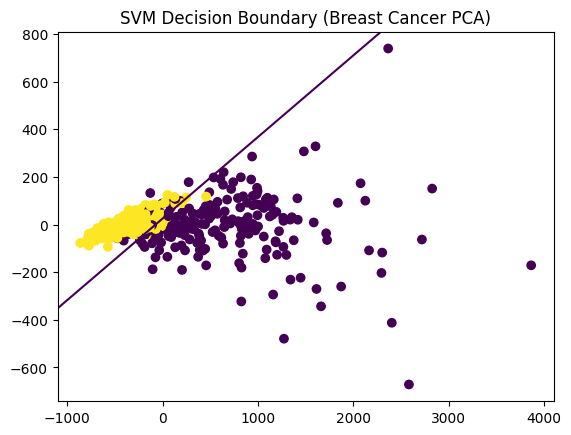

In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA


# Step 2: Load Dataset
data = datasets.load_breast_cancer()

# Step 3: Separate Features and Labels
X = data.data
y = data.target


#  Step 4: Convert to 2D using PCA (for plotting)
pca = PCA(n_components=2)
X = pca.fit_transform(X)


# Step 5: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 6: Create Model
model = SVC(kernel='linear')

# Step 7: Train
model.fit(X_train, y_train)

# Step 8: Predict
y_pred = model.predict(X_test)

# Step 9: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


#  Step 10: Plot Decision Boundary

def plot_decision_boundary(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 50)
    yy = np.linspace(ylim[0], ylim[1], 50)

    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])
    plt.title("SVM Decision Boundary (Breast Cancer PCA)")
    plt.show()


plot_decision_boundary(X, y, model)

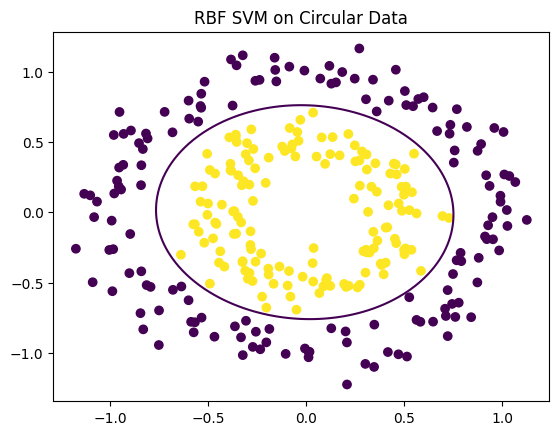

In [ ]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create circular dataset
X, y = make_circles(n_samples=300, noise=0.1, factor=0.5)

# Step 2: Train RBF SVM
model = SVC(kernel='rbf', C=1, gamma=0.5)
model.fit(X, y)


#  Step 3: Plot decision boundary

def plot_decision_boundary(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])
    plt.title("RBF SVM on Circular Data")
    plt.show()


plot_decision_boundary(X, y, model)